Mounted at /content/drive
Extracting dataset...
Done.
Path to dataset files: /content/cifake_dataset


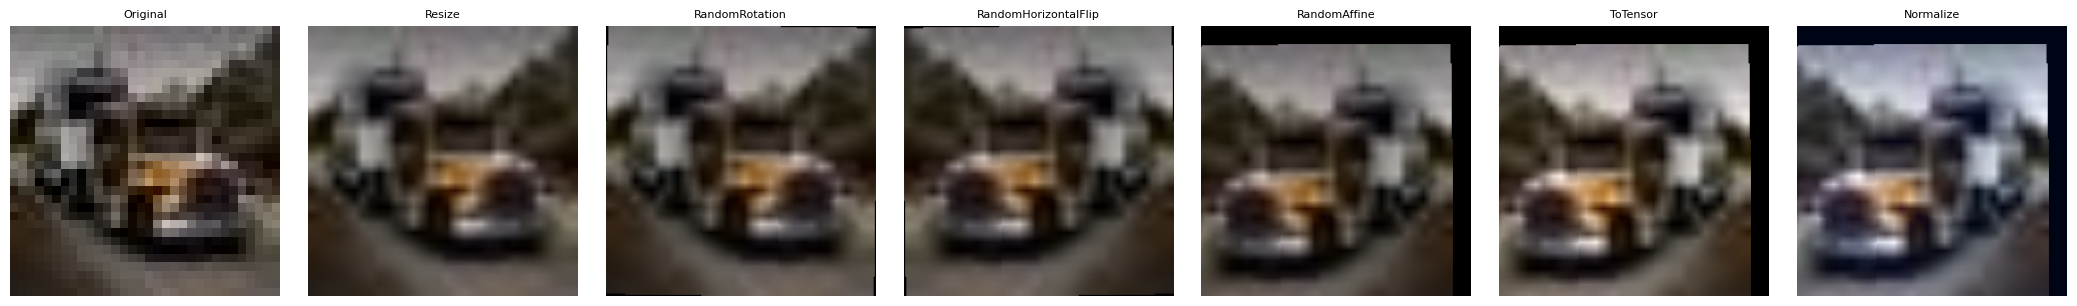

Classes: {'FAKE': 0, 'REAL': 1}
Training samples: 99000, Validation samples: 11000, Test samples: 20000
FAKE: 60000, REAL: 50000, pos_weight: 1.200

Model parameters: 25,831,201

=== Training ===
Epoch 1/25 - loss: 0.3921 - acc: 0.8386 - val_loss: 1.3016 - val_acc: 0.8785 - lr: 1.0e-03
Epoch 2/25 - loss: 0.2888 - acc: 0.8912 - val_loss: 0.6091 - val_acc: 0.9266 - lr: 1.0e-03
Epoch 3/25 - loss: 0.2877 - acc: 0.8920 - val_loss: 0.2162 - val_acc: 0.9205 - lr: 1.0e-03
Epoch 4/25 - loss: 0.2804 - acc: 0.8956 - val_loss: 0.2471 - val_acc: 0.9034 - lr: 1.0e-03
Epoch 5/25 - loss: 0.2594 - acc: 0.9051 - val_loss: 0.1978 - val_acc: 0.9341 - lr: 1.0e-03
Epoch 6/25 - loss: 0.2371 - acc: 0.9138 - val_loss: 0.2050 - val_acc: 0.9287 - lr: 1.0e-03
Epoch 7/25 - loss: 0.2260 - acc: 0.9187 - val_loss: 0.1695 - val_acc: 0.9367 - lr: 1.0e-03
Epoch 8/25 - loss: 0.2208 - acc: 0.9214 - val_loss: 0.4704 - val_acc: 0.7925 - lr: 1.0e-03
Epoch 9/25 - loss: 0.2240 - acc: 0.9192 - val_loss: 0.1568 - val_acc: 0.9446

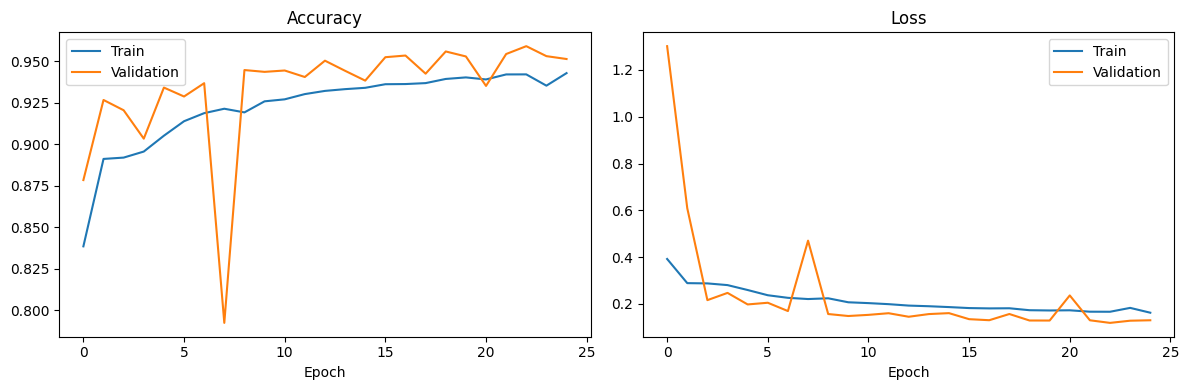

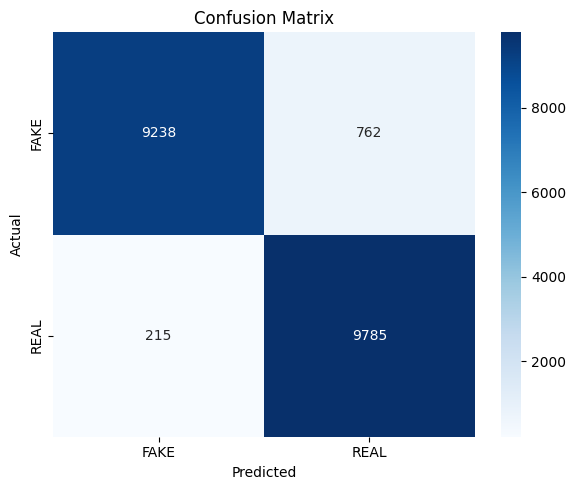

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to /content/drive/MyDrive/Dissertation/cifake_cnn_model.pth


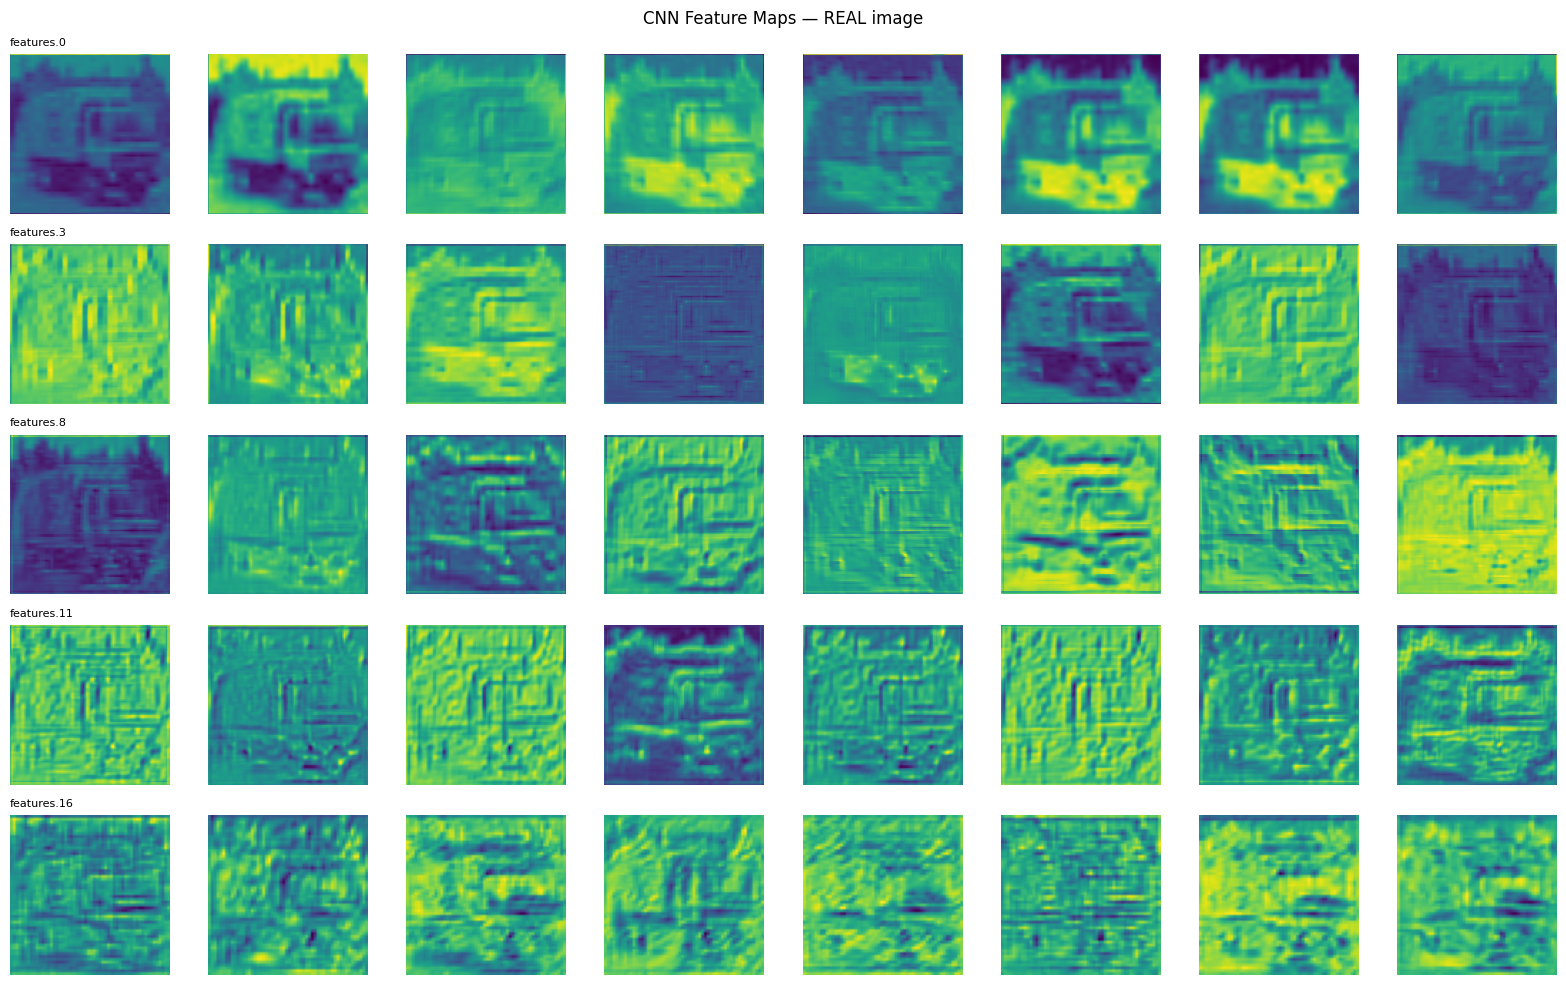

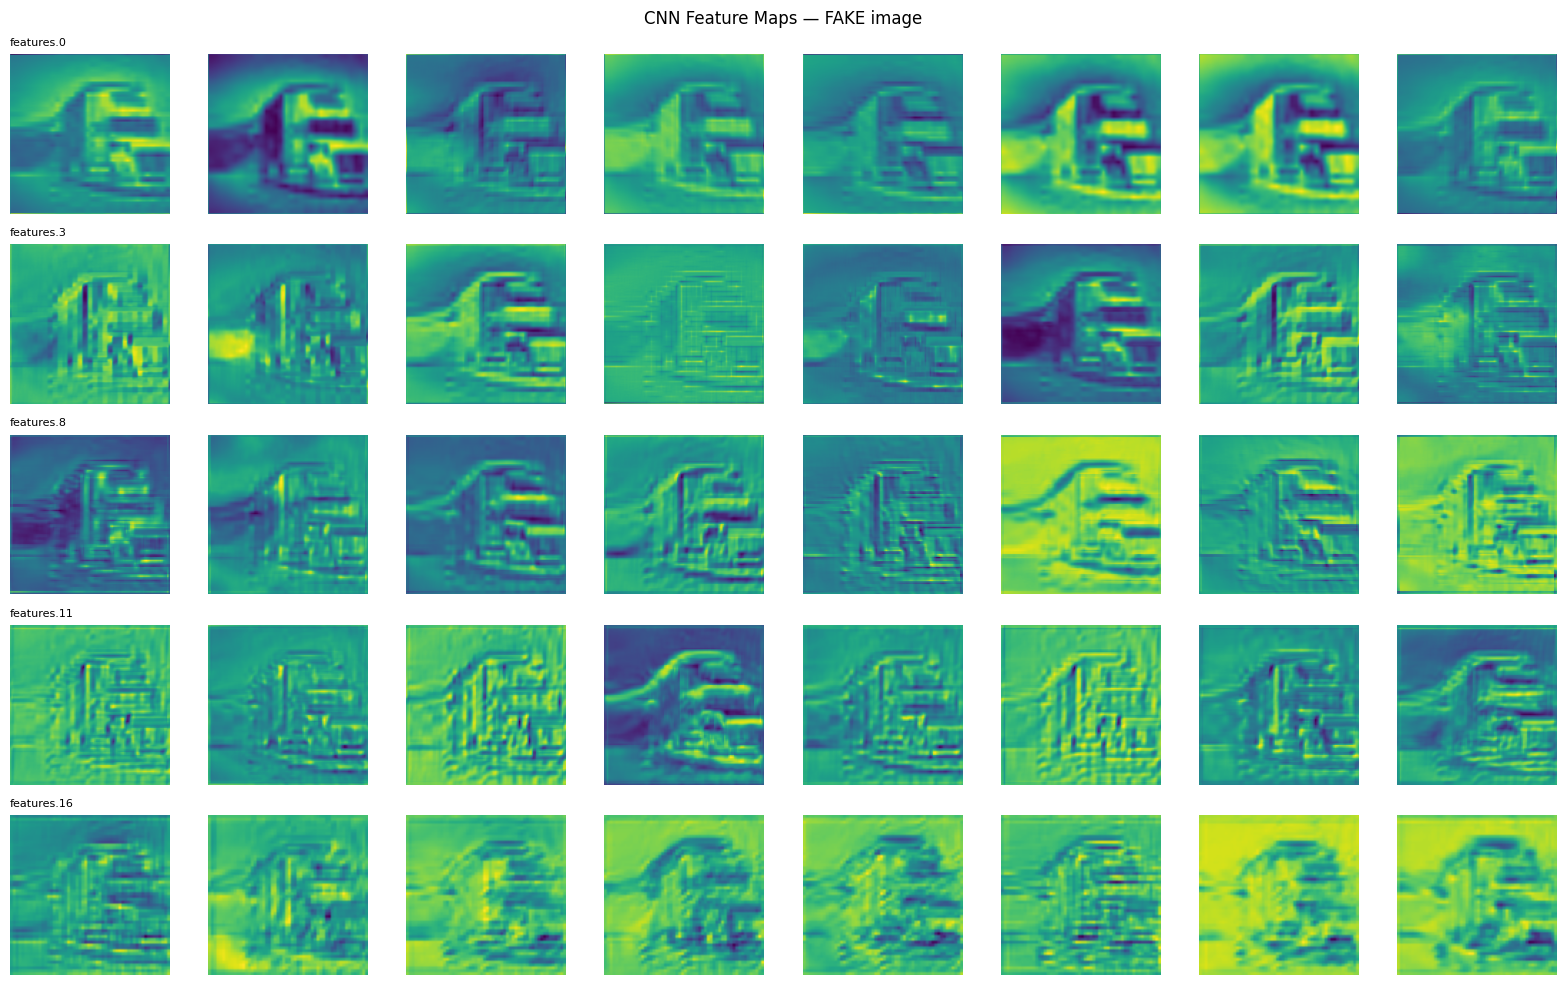

In [ ]:
#import all necessary libraries
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from PIL import Image

# Configuration
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 25
DEVICE = torch.device("cuda")

# Augmented Dataset is loaded from Google Drive
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

# Extract dataset from zip
zip_path = "/content/drive/MyDrive/Dissertation/cifake_dataset.zip"
extract_to = "/content/cifake_dataset"
if not os.path.exists(extract_to):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall("/content")
    print("Done.")
DATASET_DIR = extract_to
print("Path to dataset files:", DATASET_DIR)

# Data Loading
# CIFAKE dataset structure:
#   train/REAL/, train/FAKE/
#   test/REAL/, test/FAKE/

train_dir = os.path.join(DATASET_DIR, "train")
test_dir = os.path.join(DATASET_DIR, "test")

# Preprocessing & Data Augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # Data Augmentation applied to training images
    transforms.RandomRotation(10),             # Randomly rotate images up to 10 degrees
    transforms.RandomHorizontalFlip(),         # Randomly mirror images horizontally
    transforms.RandomAffine(                   # Random translation
        degrees=0,
        translate=(0.1, 0.1),                  # Shift up to 10% horizontally/vertically
    ),
    # Preprocessing
    transforms.ToTensor(),                     # Convert to tensor and scale to [0, 1]
    transforms.Normalize(                      # Standardize using ImageNet statistics
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# Preprocessing only, no augmentation applied to test data
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# visualize Augmentation Pipeline

def to_displayable(img):
    if isinstance(img, Image.Image):
        return np.array(img) / 255.0
    arr = img.permute(1, 2, 0).numpy()
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)


sample_path = datasets.ImageFolder(train_dir).samples[0][0]
raw_img = Image.open(sample_path).convert("RGB")

pipeline_steps = [("Original", raw_img)]
current = raw_img
for t in train_transform.transforms:
    current = t(current)
    pipeline_steps.append((type(t).__name__, current))

fig, axes = plt.subplots(1, len(pipeline_steps), figsize=(3 * len(pipeline_steps), 3))
for ax, (name, img) in zip(axes, pipeline_steps):
    ax.imshow(to_displayable(img))
    ax.set_title(name, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.savefig("cnn_augmentation_pipeline.png", dpi=150)
plt.show()

# Load datasets
full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
# Separate, untransformed copy so the validation split isn't randomly augmented each epoch
full_train_dataset_eval = datasets.ImageFolder(train_dir, transform=test_transform)

# Reserve 10% of training data for validation
val_size = int(0.1 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_indices, val_indices = random_split(range(len(full_train_dataset)), [train_size, val_size])
train_dataset = Subset(full_train_dataset, train_indices.indices)
val_dataset = Subset(full_train_dataset_eval, val_indices.indices)

test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Classes: {full_train_dataset.class_to_idx}")
print(f"Training samples: {train_size}, Validation samples: {val_size}, Test samples: {len(test_dataset)}")

# GAN augmentation adds images to FAKE only, skewing the class balance.
# Compute pos_weight from the actual counts rather than hardcoding a ratio,
# so it stays correct if N_SAMPLES (or the dataset) changes later.
class_counts = np.bincount([label for _, label in full_train_dataset.samples])
fake_count, real_count = class_counts[0], class_counts[1]
pos_weight = torch.tensor([fake_count / real_count], device=DEVICE)
print(f"FAKE: {fake_count}, REAL: {real_count}, pos_weight: {pos_weight.item():.3f}")


# CNN Model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * (IMG_SIZE // 8) * (IMG_SIZE // 8), 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.5),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CNN().to(DEVICE)
print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")

# Training Setup
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6)

# Training history
history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.float().to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.float().to(DEVICE)
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


# Training Loop with Early Stopping
best_val_loss = float("inf")
patience = 5
patience_counter = 0
best_model_state = None

print("\n=== Training ===")
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    scheduler.step(val_loss)

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+1}/{EPOCHS} - loss: {train_loss:.4f} - acc: {train_acc:.4f} "
          f"- val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f} - lr: {current_lr:.1e}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# Restore best weights
if best_model_state is not None:
    model.load_state_dict(best_model_state)

# Evaluation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images).squeeze(1)
        probs = torch.sigmoid(outputs).cpu().numpy()
        all_preds.extend(probs)
        all_labels.extend(labels.numpy())

y_true = np.array(all_labels)
y_pred_probs = np.array(all_preds)
y_pred = (y_pred_probs > 0.5).astype(int)

test_acc = (y_pred == y_true).mean()
print(f"\nTest Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["FAKE", "REAL"]))

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["accuracy"], label="Train")
axes[0].plot(history["val_accuracy"], label="Validation")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["loss"], label="Train")
axes[1].plot(history["val_loss"], label="Validation")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["FAKE", "REAL"], yticklabels=["FAKE", "REAL"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# Save Model
from google.colab import drive
drive.mount("/content/drive", force_remount=False)
save_dir = "/content/drive/MyDrive/Dissertation"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "cifake_cnn_model.pth")

torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

# Feature Map Visualisation
# Hooks capture each Conv2d layer's output so its learned filters can be inspected directly

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1)


# One REAL and one FAKE test image so activations can be compared side by side
real_idx = next(i for i, (_, label) in enumerate(test_dataset.samples) if label == 1)
fake_idx = next(i for i, (_, label) in enumerate(test_dataset.samples) if label == 0)
sample_images = {
    "REAL": test_dataset[real_idx][0].unsqueeze(0).to(DEVICE),
    "FAKE": test_dataset[fake_idx][0].unsqueeze(0).to(DEVICE),
}

feature_maps = {}


def make_hook(name):
    def hook(module, input, output):
        feature_maps[name] = output.detach().cpu()
    return hook


conv_layers = [(name, module) for name, module in model.features.named_children() if isinstance(module, nn.Conv2d)]
hooks = [module.register_forward_hook(make_hook(name)) for name, module in conv_layers]

model.eval()
for label, img in sample_images.items():
    feature_maps.clear()
    with torch.no_grad():
        model(img)

    fig, axes = plt.subplots(len(conv_layers), 8, figsize=(16, 2 * len(conv_layers)))
    for row, (name, _) in enumerate(conv_layers):
        fmap = feature_maps[name][0]  # (C, H, W)
        for col in range(8):
            axes[row, col].imshow(fmap[col].numpy(), cmap="viridis")
            axes[row, col].axis("off")
        axes[row, 0].set_title(f"features.{name}", fontsize=8, loc="left")

    fig.suptitle(f"CNN Feature Maps — {label} image")
    plt.tight_layout()
    plt.savefig(f"cnn_feature_maps_{label.lower()}.png", dpi=150)
    plt.show()

for h in hooks:
    h.remove()